# Navier–Stokes PINNsFormer + ConFIG（2-loss）

保持上传 notebook 的 seed、800 点、5-step、模型结构、PDE、黏性系数和 1000 外层迭代。**唯一必须改变的训练设置是 optimizer/update mechanism：LBFGS → Adam + ConFIG**。原因见同目录 README。`LR=1e-4` 是新增超参数，后续必须用同 LR 的 `Adam + simple-sum` 做公平对照。

In [3]:
from pathlib import Path
import os, sys, time, random
import numpy as np
import torch
import matplotlib.pyplot as plt
from tqdm import tqdm

CONFIG_ROOT = Path(os.environ.get("CONFIG_ROOT", "/home/simplexity/cyt/ConFIG-main"))
PINNSFORMER_ROOT = Path(os.environ.get("PINNSFORMER_ROOT", "/home/simplexity/cyt/pinnsformer-main"))
DATA_PATH = PINNSFORMER_ROOT / "demo" / "navier_stokes" / "cylinder_nektar_wake.mat"
sys.path.insert(0, str(CONFIG_ROOT))

from conflictfree.grad_operator import ConFIGOperator
from conflictfree.utils import apply_gradient_vector_para_based
from gradient_diagnostics import gradient_vector, ConflictTracker
from navier_stokes_common import PINNsformer, init_weights, get_n_params, load_training_data, compute_ns_losses, evaluation_tensors

assert DATA_PATH.exists(), DATA_PATH

In [4]:
SEED=0
DEVICE="cuda:0"
N_TRAIN=800
NUM_STEP=5
TIME_STEP=1e-2
EPOCHS=1000
LR=1e-4
DIAG_INTERVAL=10

np.random.seed(SEED); random.seed(SEED); torch.manual_seed(SEED); torch.cuda.manual_seed(SEED)
assert torch.cuda.is_available()
device=torch.device(DEVICE)
batch, reference = load_training_data(DATA_PATH, device, seed=SEED, n_train=N_TRAIN, num_step=NUM_STEP, time_step=TIME_STEP)
print(torch.cuda.get_device_name(device), batch["x"].shape)

NVIDIA GeForce GTX 1080 Ti torch.Size([800, 5, 1])


In [5]:
model=PINNsformer(d_out=2,d_hidden=512,d_model=32,N=1,heads=2).to(device)
model.apply(init_weights)
optimizer=torch.optim.Adam(model.parameters(),lr=LR)
config_operator=ConFIGOperator()
print("params:",get_n_params(model))

params: 454106


In [6]:
torch.cuda.empty_cache(); torch.cuda.reset_peak_memory_stats(device)
history=[]
tracker=ConflictTracker("data","physics")
start=time.time()

for step in tqdm(range(EPOCHS)):
    losses=compute_ns_losses(model,batch["x"],batch["y"],batch["t"],batch["u"],batch["v"])
    g_data=gradient_vector(losses["data"],model,retain_graph=True)
    g_physics=gradient_vector(losses["physics"],model,retain_graph=False)
    cosine=tracker.update({"data":g_data,"physics":g_physics})
    g_config=config_operator.calculate_gradient(torch.stack([g_data,g_physics]),losses=[losses["data"].detach(),losses["physics"].detach()])
    optimizer.zero_grad(set_to_none=True)
    apply_gradient_vector_para_based(model,g_config)
    optimizer.step()
    if step % DIAG_INTERVAL == 0 or step == EPOCHS-1:
        history.append({"step":step,"total":float(losses["total"].detach()),"data":float(losses["data"].detach()),"physics":float(losses["physics"].detach()),"g_data_norm":float(g_data.norm()),"g_physics_norm":float(g_physics.norm()),"cosine":cosine,"conflict":int(np.isfinite(cosine) and cosine<0)})

torch.cuda.synchronize()
elapsed=time.time()-start
print(f"wall time: {elapsed:.2f}s ({elapsed/60:.2f}min)")
print(f"peak allocated: {torch.cuda.max_memory_allocated(device)/1024**2:.2f} MiB")
print("conflict:",tracker.summary())

100%|██████████| 1000/1000 [11:14<00:00,  1.48it/s]

wall time: 674.29s (11.24min)
peak allocated: 7671.19 MiB
conflict: {'n': 1000, 'mean_cosine': -0.35892330276354917, 'min_cosine': -0.9880205988883972, 'max_cosine': 0.8332501649856567, 'conflict_rate': 0.69}


In [7]:
OUTPUT_DIR=Path("./outputs/navier_stokes_config"); OUTPUT_DIR.mkdir(parents=True,exist_ok=True)
MODEL_PATH=OUTPUT_DIR/"ns_pinnsformer_config_2loss.pt"
HISTORY_PATH=OUTPUT_DIR/"ns_pinnsformer_config_2loss_history.npz"
torch.save(model.state_dict(),MODEL_PATH)
keys=list(history[0]); np.savez(HISTORY_PATH,**{k:np.asarray([r[k] for r in history]) for k in keys})
print(MODEL_PATH.resolve()); print(HISTORY_PATH.resolve())

/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_config/ns_pinnsformer_config_2loss.pt
/home/simplexity/cyt/pinnsformer-main/pinnsformer-config/outputs/navier_stokes_config/ns_pinnsformer_config_2loss_history.npz


## Evaluation

上传/上游 notebook 训练用 `u=psi_y, v=-psi_x`，测试 cell 却交换为 `u=psi_x, v=-psi_y`。这里明确按**训练一致定义**评估，不修改原 notebook。

In [8]:
ev, truth = evaluation_tensors(reference,device,snap=100,num_step=NUM_STEP,time_step=TIME_STEP)
psi_p=model(ev["x"],ev["y"],ev["t"]); psi=psi_p[:,:,0:1]; p_pred=psi_p[:,:,1:2]
u_pred=torch.autograd.grad(psi,ev["y"],torch.ones_like(psi),retain_graph=True)[0]
v_pred=-torch.autograd.grad(psi,ev["x"],torch.ones_like(psi))[0]
u_pred=u_pred.detach().cpu().numpy()[:,0]; v_pred=v_pred.detach().cpu().numpy()[:,0]; p_pred=p_pred.detach().cpu().numpy()[:,0]
for name,pred in [("u",u_pred),("v",v_pred),("p",p_pred)]:
    err=np.linalg.norm(truth[name]-pred,2)/np.linalg.norm(truth[name],2)
    print(f"{name} relative L2 = {err:.6f}")

u relative L2 = 0.043878
v relative L2 = 0.167616
p relative L2 = 0.963713


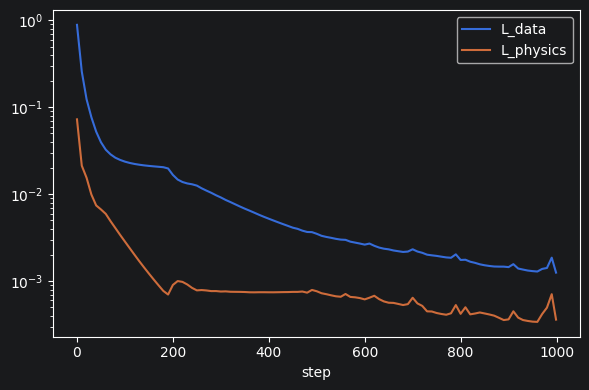

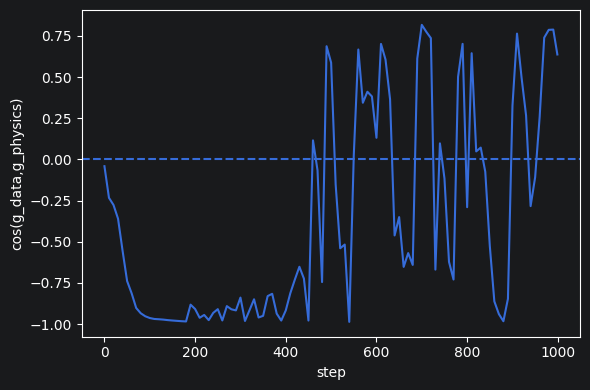

In [9]:
h=np.load(HISTORY_PATH); s=h["step"]
plt.figure(figsize=(6,4)); plt.semilogy(s,h["data"],label="L_data"); plt.semilogy(s,h["physics"],label="L_physics"); plt.legend(); plt.xlabel("step"); plt.tight_layout(); plt.show()
plt.figure(figsize=(6,4)); plt.plot(s,h["cosine"]); plt.axhline(0,linestyle="--"); plt.xlabel("step"); plt.ylabel("cos(g_data,g_physics)"); plt.tight_layout(); plt.show()